In [ ]:
# T E O R I A

In [1]:
from scipy import stats
import numpy as np

# Generar datos normales
datos_normales = np.random.normal(loc=100, scale=15, size=1000)

# Calcular probabilidades
prob_menor_85 = stats.norm.cdf(85, loc=100, scale=15)  # P(X < 85)
prob_entre_85_115 = stats.norm.cdf(115, 100, 15) - stats.norm.cdf(85, 100, 15)

print(f"P(X < 85): {prob_menor_85:.3f}")
print(f"P(85 < X < 115): {prob_entre_85_115:.3f}")

P(X < 85): 0.159
P(85 < X < 115): 0.683


In [2]:
# Probabilidad de exactamente k conversiones en n visitantes
n_visitantes = 100
p_conversion = 0.05  # 5% tasa de conversión

prob_exactly_3 = stats.binom.pmf(3, n_visitantes, p_conversion)
prob_at_least_5 = 1 - stats.binom.cdf(4, n_visitantes, p_conversion)

print(f"P(exactamente 3 conversiones): {prob_exactly_3:.4f}")
print(f"P(al menos 5 conversiones): {prob_at_least_5:.4f}")

P(exactamente 3 conversiones): 0.1396
P(al menos 5 conversiones): 0.5640


In [3]:
# Tasa de pedidos por hora
lambda_pedidos = 12  # 12 pedidos por hora promedio

prob_exactly_10 = stats.poisson.pmf(10, lambda_pedidos)
prob_more_than_15 = 1 - stats.poisson.cdf(15, lambda_pedidos)

print(f"P(exactamente 10 pedidos/hora): {prob_exactly_10:.4f}")
print(f"P(más de 15 pedidos/hora): {prob_more_than_15:.4f}")

P(exactamente 10 pedidos/hora): 0.1048
P(más de 15 pedidos/hora): 0.1556


In [4]:
# Estimación del ingreso promedio de clientes
ingresos_muestra = np.random.lognormal(10, 0.5, 100)  # Muestra de 100 clientes
media_muestra = np.mean(ingresos_muestra)
error_estandar = stats.sem(ingresos_muestra)  # Error estándar

# Intervalo de confianza al 95%
intervalo_confianza = stats.t.interval(0.95, len(ingresos_muestra)-1, 
                                     loc=media_muestra, scale=error_estandar)

print(f"Media muestral: ${media_muestra:.2f}")
print(f"Error estándar: ${error_estandar:.2f}")
print(f"IC 95%: (${intervalo_confianza[0]:.2f}, ${intervalo_confianza[1]:.2f})")

Media muestral: $24983.11
Error estándar: $1303.96
IC 95%: ($22395.78, $27570.45)


In [ ]:
# >>>>>>>>>>      P R A C T I C A     <<<<<<<<<<

In [5]:
# Análisis de distribución de compras por cliente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generar dataset de comportamiento de clientes
np.random.seed(42)
n_clientes = 10000

# Simular compras por cliente (distribución Poisson)
compras_por_cliente = np.random.poisson(lam=2.5, size=n_clientes)

# Simular valor de compra (distribución log-normal)
valor_compra = np.random.lognormal(mean=4.5, sigma=0.8, size=n_clientes)

# Crear DataFrame
df = pd.DataFrame({
    'cliente_id': range(1, n_clientes + 1),
    'compras_anuales': compras_por_cliente,
    'valor_promedio_compra': valor_compra,
    'gasto_total_anual': compras_por_cliente * valor_compra
})

print("Análisis probabilístico de comportamiento de clientes")
print("=" * 55)
print(f"Total clientes analizados: {len(df):,}")
print(f"Compras promedio por cliente/año: {df['compras_anuales'].mean():.2f}")
print(f"Valor promedio de compra: ${df['valor_promedio_compra'].mean():.2f}")

Análisis probabilístico de comportamiento de clientes
Total clientes analizados: 10,000
Compras promedio por cliente/año: 2.51
Valor promedio de compra: $122.82


In [6]:
df

,cliente_id,compras_anuales,valor_promedio_compra,gasto_total_anual
0,1,4,174.942406,699.769624
1,2,1,371.546565,371.546565
2,3,3,194.429683,583.289049
3,4,3,50.594840,151.784519
4,5,1,86.471619,86.471619
...,...,...,...,...
9995,9996,2,258.137067,516.274134
9996,9997,1,61.276441,61.276441
9997,9998,3,40.320559,120.961676
9998,9999,1,170.910533,170.910533


In [7]:
# Análisis de distribuciones y probabilidades
# Análisis de distribución de compras
print("\nDISTRIBUCIÓN DE COMPRAS ANUALES")
print("-" * 35)
print(df['compras_anuales'].value_counts().sort_index().head(10))

# Probabilidades usando distribución de Poisson
lambda_compras = df['compras_anuales'].mean()

print(f"\nProbabilidades (usando distribución de Poisson λ={lambda_compras:.2f}):")
print(f"P(0 compras/año): {stats.poisson.pmf(0, lambda_compras):.4f}")
print(f"P(1 compra/año): {stats.poisson.pmf(1, lambda_compras):.4f}")
print(f"P(5+ compras/año): {1 - stats.poisson.cdf(4, lambda_compras):.4f}")

# Análisis de valor de compra
print(f"\nANÁLISIS DE VALOR DE COMPRA")
print("-" * 30)
print(f"Media: ${df['valor_promedio_compra'].mean():.2f}")
print(f"Mediana: ${df['valor_promedio_compra'].median():.2f}")
print(f"Desviación estándar: ${df['valor_promedio_compra'].std():.2f}")

# Test de normalidad para valor de compra
_, p_valor = stats.normaltest(df['valor_promedio_compra'])
print(f"Test de normalidad (p-valor): {p_valor:.4f}")
print(f"¿Es normal?: {'No' if p_valor < 0.05 else 'Sí'}")


DISTRIBUCIÓN DE COMPRAS ANUALES
-----------------------------------
compras_anuales
0     803
1    2088
2    2497
3    2197
4    1317
5     677
6     280
7      95
8      32
9       9
Name: count, dtype: int64

Probabilidades (usando distribución de Poisson λ=2.51):
P(0 compras/año): 0.0816
P(1 compra/año): 0.2045
P(5+ compras/año): 0.1096

ANÁLISIS DE VALOR DE COMPRA
------------------------------
Media: $122.82
Mediana: $89.13
Desviación estándar: $116.85
Test de normalidad (p-valor): 0.0000
¿Es normal?: No


C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


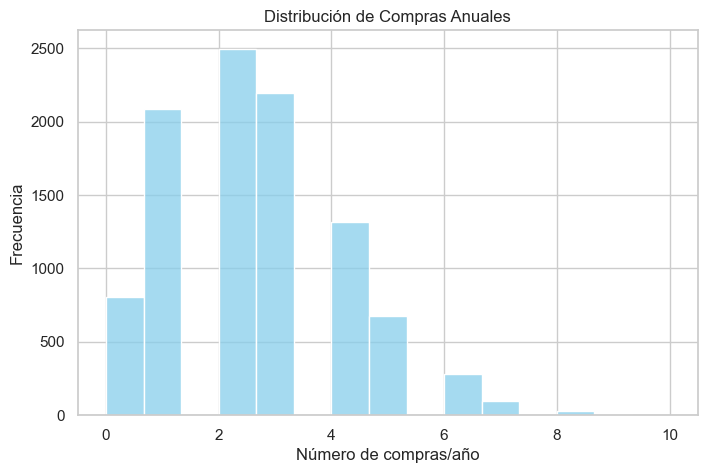

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


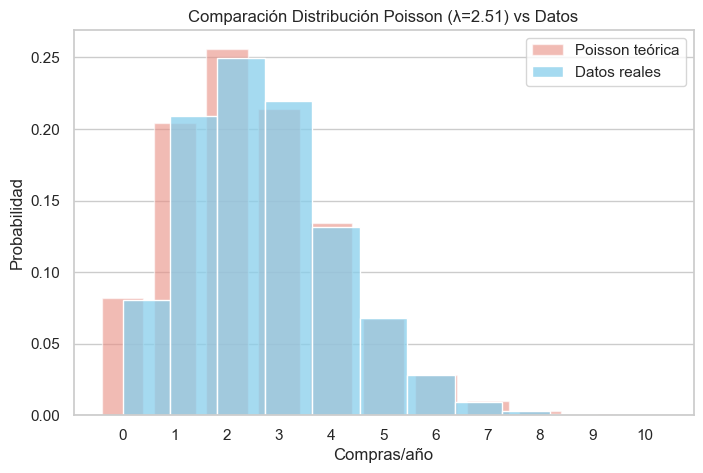

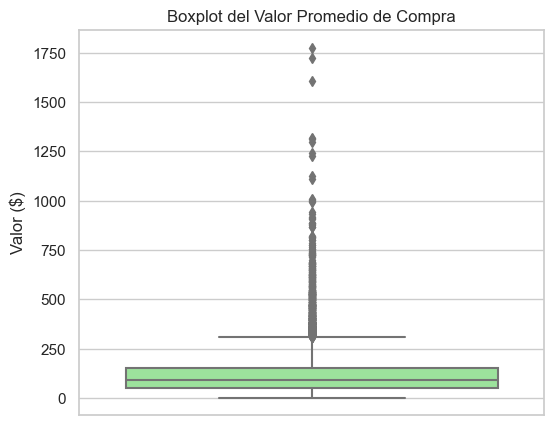

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


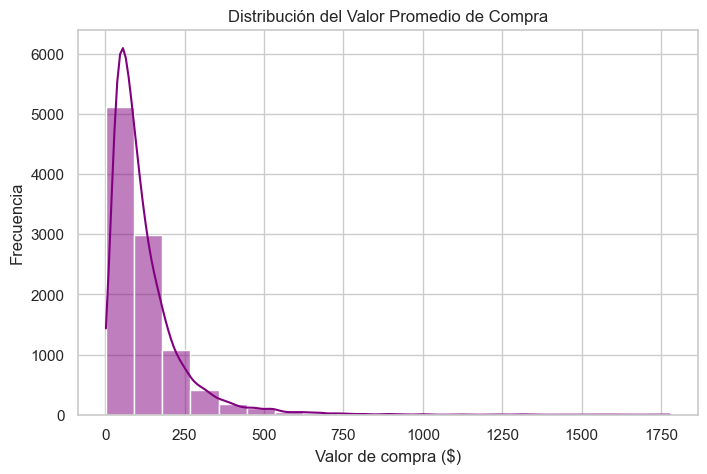

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Configuración estética
sns.set(style="whitegrid", palette="muted")

# 1. Histograma de compras anuales ---
plt.figure(figsize=(8,5))
sns.histplot(df['compras_anuales'], bins=15, kde=False, color="skyblue")
plt.title("Distribución de Compras Anuales")
plt.xlabel("Número de compras/año")
plt.ylabel("Frecuencia")
plt.show()

# 2. Distribución Poisson vs datos reales ---
lambda_compras = df['compras_anuales'].mean()
x = np.arange(0, df['compras_anuales'].max()+1)
poisson_probs = stats.poisson.pmf(x, lambda_compras)

plt.figure(figsize=(8,5))
sns.barplot(x=x, y=poisson_probs, color="salmon", alpha=0.6, label="Poisson teórica")
sns.histplot(df['compras_anuales'], stat="probability", bins=len(x), color="skyblue", label="Datos reales")
plt.title(f"Comparación Distribución Poisson (λ={lambda_compras:.2f}) vs Datos")
plt.xlabel("Compras/año")
plt.ylabel("Probabilidad")
plt.legend()
plt.show()

# 3. Boxplot del valor promedio de compra ---
plt.figure(figsize=(6,5))
sns.boxplot(y=df['valor_promedio_compra'], color="lightgreen")
plt.title("Boxplot del Valor Promedio de Compra")
plt.ylabel("Valor ($)")
plt.show()

# 4. Histograma + curva KDE del valor promedio de compra ---
plt.figure(figsize=(8,5))
sns.histplot(df['valor_promedio_compra'], bins=20, kde=True, color="purple")
plt.title("Distribución del Valor Promedio de Compra")
plt.xlabel("Valor de compra ($)")
plt.ylabel("Frecuencia")
plt.show()



In [9]:
# Aplicación del teorema del límite central
# Demostración del teorema del límite central
n_muestras = 1000
tamano_muestra = 50

medias_muestrales = []
for _ in range(n_muestras):
    muestra = np.random.choice(df['gasto_total_anual'], size=tamano_muestra, replace=True)
    medias_muestrales.append(np.mean(muestra))

# Análisis de la distribución de medias muestrales
medias_array = np.array(medias_muestrales)
media_muestral_global = np.mean(medias_array)
error_estandar = np.std(medias_array)

print(f"\nTEOREMA DEL LÍMITE CENTRAL")
print("-" * 30)
print(f"Media de medias muestrales: ${media_muestral_global:.2f}")
print(f"Media poblacional real: ${df['gasto_total_anual'].mean():.2f}")
print(f"Error estándar de medias: ${error_estandar:.2f}")

# Intervalo de confianza
z_score = 1.96  # 95% confianza
margen_error = z_score * error_estandar
ic_inferior = media_muestral_global - margen_error
ic_superior = media_muestral_global + margen_error

print(f"Intervalo de confianza 95%: (${ic_inferior:.2f}, ${ic_superior:.2f})")
print(f"Margen de error: ${margen_error:.2f}")


TEOREMA DEL LÍMITE CENTRAL
------------------------------
Media de medias muestrales: $309.30
Media poblacional real: $306.16
Error estándar de medias: $55.80
Intervalo de confianza 95%: ($199.93, $418.67)
Margen de error: $109.37


C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


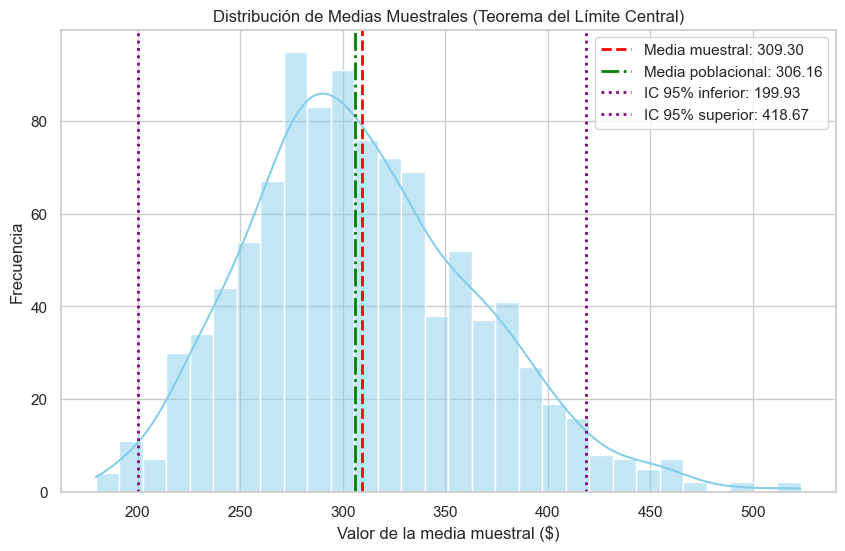

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


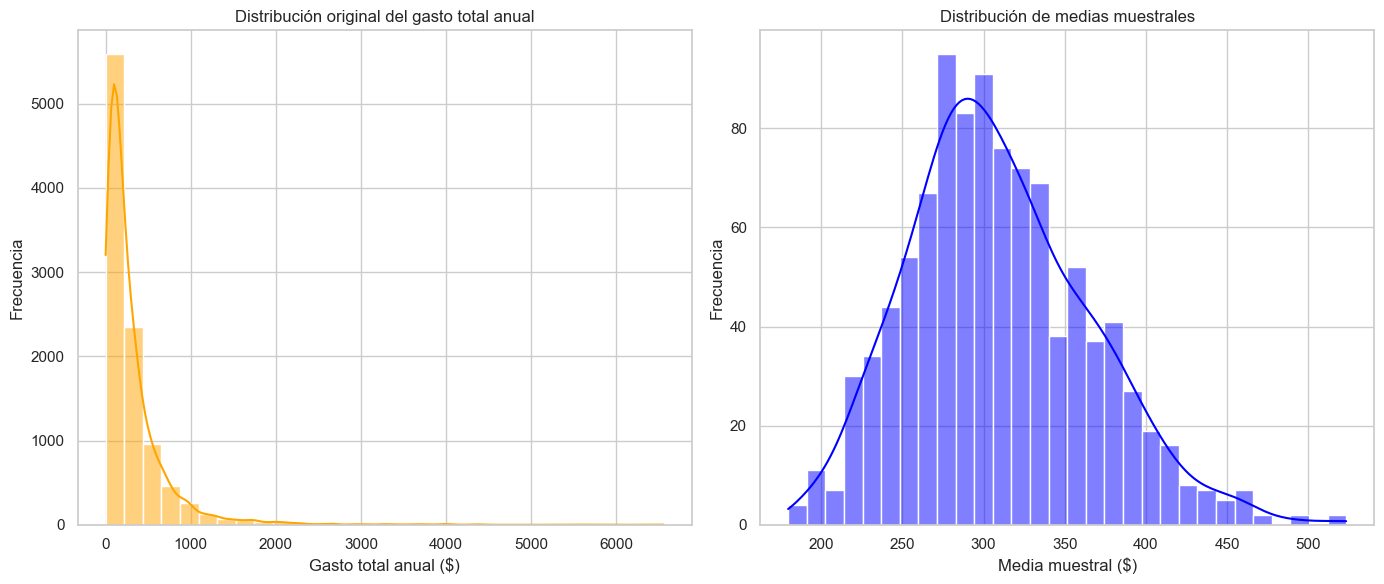

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Visualización del Teorema del Límite Central ---
plt.figure(figsize=(10,6))
sns.histplot(medias_array, bins=30, kde=True, color="skyblue")

# Línea de la media muestral global
plt.axvline(media_muestral_global, color="red", linestyle="--", linewidth=2, label=f"Media muestral: {media_muestral_global:.2f}")

# Línea de la media poblacional real
plt.axvline(df['gasto_total_anual'].mean(), color="green", linestyle="-.", linewidth=2, label=f"Media poblacional: {df['gasto_total_anual'].mean():.2f}")

# Intervalo de confianza
plt.axvline(ic_inferior, color="purple", linestyle=":", linewidth=2, label=f"IC 95% inferior: {ic_inferior:.2f}")
plt.axvline(ic_superior, color="purple", linestyle=":", linewidth=2, label=f"IC 95% superior: {ic_superior:.2f}")

plt.title("Distribución de Medias Muestrales (Teorema del Límite Central)")
plt.xlabel("Valor de la media muestral ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# Gráfico comparativo: distribución original vs medias muestrales ---
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(df['gasto_total_anual'], bins=30, kde=True, color="orange", ax=axes[0])
axes[0].set_title("Distribución original del gasto total anual")
axes[0].set_xlabel("Gasto total anual ($)")
axes[0].set_ylabel("Frecuencia")

sns.histplot(medias_array, bins=30, kde=True, color="blue", ax=axes[1])
axes[1].set_title("Distribución de medias muestrales")
axes[1].set_xlabel("Media muestral ($)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Visualizaciones guardadas como 'distribuciones_probabilidad_clientes.png'


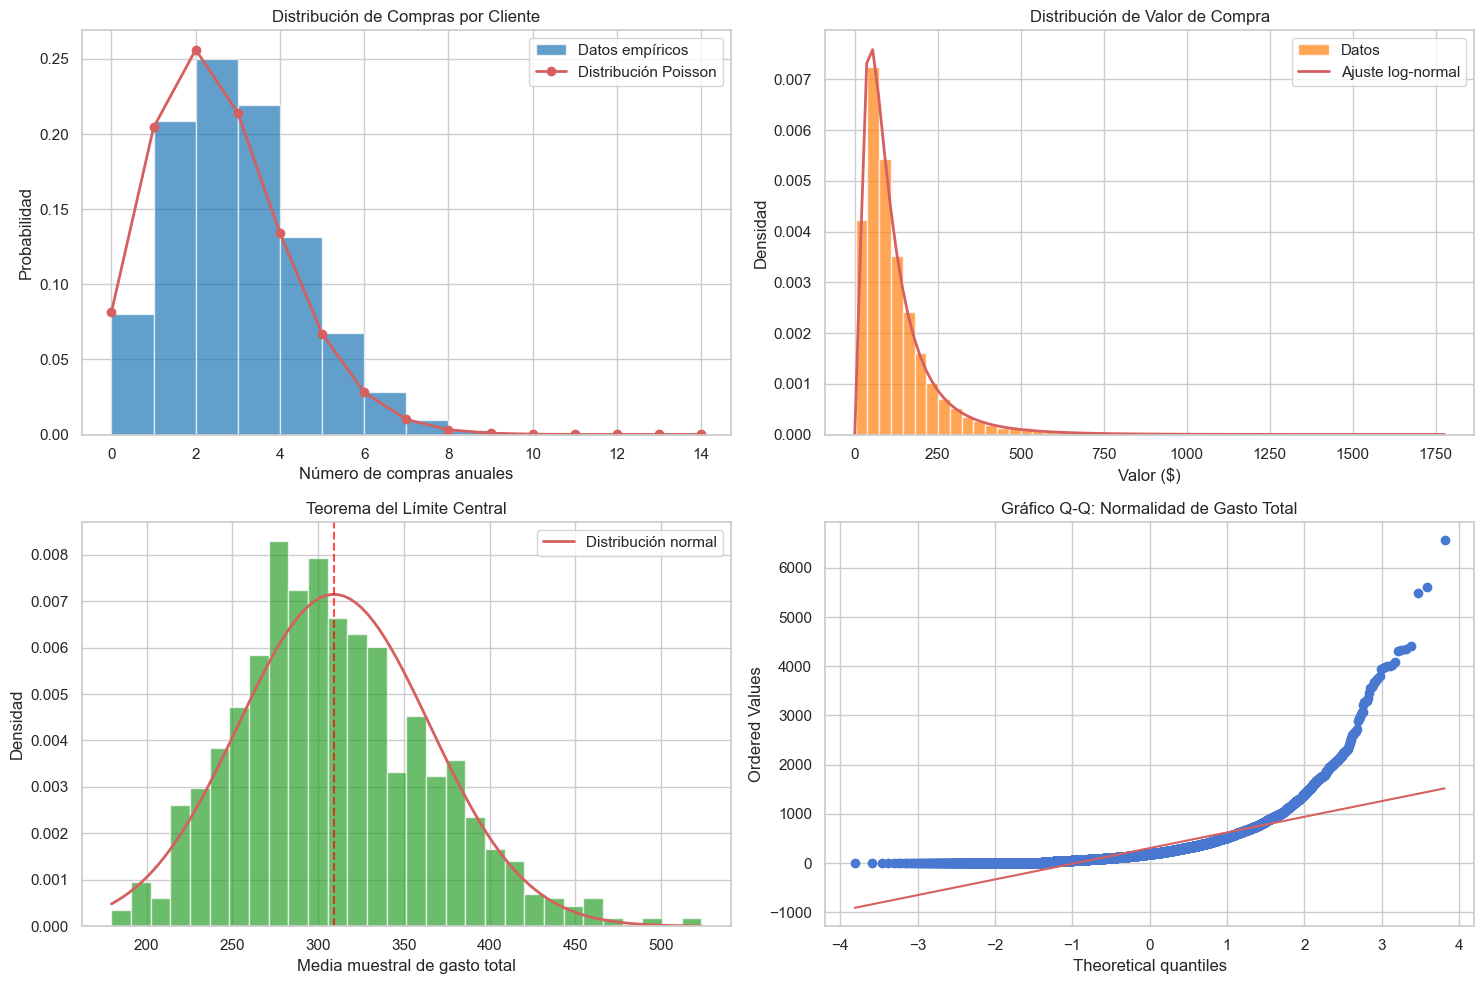

In [11]:
# Visualización de distribuciones
# Crear visualización de distribuciones
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de compras (comparar empírica vs teórica)
ax1.hist(df['compras_anuales'], bins=range(0, 15), alpha=0.7, density=True, 
        color='#1f77b4', label='Datos empíricos')

x_poisson = range(0, 15)
y_poisson = [stats.poisson.pmf(x, lambda_compras) for x in x_poisson]
ax1.plot(x_poisson, y_poisson, 'ro-', label='Distribución Poisson', linewidth=2)
ax1.set_title('Distribución de Compras por Cliente')
ax1.set_xlabel('Número de compras anuales')
ax1.set_ylabel('Probabilidad')
ax1.legend()

# Distribución de valor de compra
ax2.hist(df['valor_promedio_compra'], bins=50, alpha=0.7, density=True, 
        color='#ff7f0e', label='Datos')

# Ajuste de distribución log-normal
params = stats.lognorm.fit(df['valor_promedio_compra'])
x_fit = np.linspace(0, df['valor_promedio_compra'].max(), 100)
y_fit = stats.lognorm.pdf(x_fit, *params)
ax2.plot(x_fit, y_fit, 'r-', linewidth=2, label='Ajuste log-normal')
ax2.set_title('Distribución de Valor de Compra')
ax2.set_xlabel('Valor ($)')
ax2.set_ylabel('Densidad')
ax2.legend()

# Distribución de medias muestrales (TLC)
ax3.hist(medias_array, bins=30, alpha=0.7, density=True, color='#2ca02c')

# Añadir curva normal teórica
x_normal = np.linspace(medias_array.min(), medias_array.max(), 100)
y_normal = stats.norm.pdf(x_normal, media_muestral_global, error_estandar)
ax3.plot(x_normal, y_normal, 'r-', linewidth=2, label='Distribución normal')
ax3.axvline(media_muestral_global, color='red', linestyle='--', alpha=0.7)
ax3.set_title('Teorema del Límite Central')
ax3.set_xlabel('Media muestral de gasto total')
ax3.set_ylabel('Densidad')
ax3.legend()

# Gráfico Q-Q para normalidad
stats.probplot(df['gasto_total_anual'], dist="norm", plot=ax4)
ax4.set_title('Gráfico Q-Q: Normalidad de Gasto Total')

plt.tight_layout()
plt.savefig('distribuciones_probabilidad_clientes.png', dpi=300, bbox_inches='tight')
print("\nVisualizaciones guardadas como 'distribuciones_probabilidad_clientes.png'")

In [ ]:
"""
Distribuciones probabilísticas vs. distribución normal
1. Distribución de Poisson para conteos
- Aplicación: Modela eventos discretos en un intervalo fijo (por ejemplo, número de compras anuales por cliente).
- Ventaja: Captura la naturaleza asimétrica y discreta de los conteos, donde muchos clientes compran pocas veces
y pocos compran mucho.
- Comparación con normal:
La normal es simétrica y continua, lo que no refleja bien la concentración en valores bajos 
ni la cola larga de clientes frecuentes.
Poisson permite estimar probabilidades como P(X=0) o P(X\geq 5), útiles para segmentación y targeting.

2. Distribución log-normal para valores monetarios
- Aplicación: Modela variables positivas y sesgadas, como el valor de compra o gasto total.
- Ventaja: Refleja que la mayoría de los clientes gastan poco, pero hay una minoría con gastos muy altos (cola derecha).
- Comparación con normal:
La normal puede asignar probabilidades a valores negativos, lo cual es inaplicable en contextos financieros.
La log-normal se ajusta mejor a la heterogeneidad del gasto, permitiendo análisis más realistas y segmentaciones por valor.

Teorema del Límite Central (TLC) y estadística paramétrica
- tal como dice el:"Si tomamos muchas muestras aleatorias de tamaño suficiente de una población (aunque no sea normal),
la distribución de las medias muestrales tiende a ser normal."

Lo anterior es clave porque:
- Permite aplicar estadística paramétrica (intervalos de confianza, pruebas z, etc.) aunque la variable original no sea normal.
- Justifica el uso de métodos inferenciales robustos en análisis de clientes, como estimación de gasto promedio,
comparación entre segmentos, etc.
En este caso:
- Aunque el gasto total anual tiene una distribución sesgada (como se ve en el histograma), 
las medias muestrales obtenidas por bootstrap se distribuyen normalmente.
- Esto habilita el uso de intervalos de confianza y margen de error, fundamentales para reportes ejecutivos y toma de decisiones.

En resumen, modelar con Poisson y log-normal respeta la naturaleza real del comportamiento del cliente, 
mientras que el TLC permite usar herramientas estadísticas clásicas con confianza, 
incluso cuando los datos originales no son normales.
"""
